# TraceWinEnv one-step debug

This notebook runs the smallest useful TraceWinEnv check:

1. verify that SSH to `comunian@localhost` is reachable;
2. instantiate `TraceWinEnv`;
3. call `reset()`;
4. call one `step()` with zero action;
5. print the simulator result, errors, score, and files written in `calc_dir`.

It is meant for debugging TraceWin itself, not for training.

In [1]:
from __future__ import annotations

import os
import subprocess
import sys
import traceback
import time
from pathlib import Path

import numpy as np

PROJECT_PARENT = Path('/mnt/shared_volume/FEDERICO_TESI')
if str(PROJECT_PARENT) not in sys.path:
    sys.path.insert(0, str(PROJECT_PARENT))

os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')

from beam_optimization.config.paths import DEFAULT_TRACEWIN_INI
from beam_optimization.env.tracewin_env import TraceWinEnv

project_file = DEFAULT_TRACEWIN_INI
calc_dir = PROJECT_PARENT / 'beam_optimization/env/tracewin_env/tracewin/TraceWin_workspace/calc_debug_env'

print(f'project_file = {project_file}')
print(f'calc_dir     = {calc_dir}')

project_file = /mnt/shared_volume/FEDERICO_TESI/beam_optimization/env/tracewin_env/tracewin/TraceWin_workspace/condensed.ini
calc_dir     = /mnt/shared_volume/FEDERICO_TESI/beam_optimization/env/tracewin_env/tracewin/TraceWin_workspace/calc_debug_env


In [2]:
def list_calc_files(path: Path) -> None:
    if not path.exists():
        print(f'calc_dir does not exist: {path}')
        return
    files = sorted(p for p in path.iterdir() if p.is_file())
    if not files:
        print('calc_dir is empty')
        return
    for p in files:
        print(f'{p.name:<28} {p.stat().st_size:>12,} bytes')


def print_sim_result(label: str, info: dict) -> None:
    result = info.get('sim_result')
    print(f'\n[{label}]')
    print(f"score = {info.get('score')}")
    if result is None:
        print('sim_result missing')
        return
    print(f'success     = {result.success}')
    print(f'source      = {result.source}')
    print(f'score_val   = {result.score_val}')
    print(f'error       = {result.error}')
    print(f'beam_states = {None if result.beam_states is None else result.beam_states.shape}')
    print(f'metadata    = {result.metadata}')

In [3]:
# TraceWin is launched through SSH as comunian@localhost. Check that first.
ssh_cmd = [
    'ssh', '-F', '/dev/null',
    '-o', 'BatchMode=yes',
    '-o', 'ConnectTimeout=5',
    'comunian@localhost',
    'echo tracewin-ssh-ok',
]

try:
    ssh_check = subprocess.run(ssh_cmd, timeout=10, capture_output=True, text=True)
    print('returncode:', ssh_check.returncode)
    print('stdout:', ssh_check.stdout.strip())
    print('stderr:', ssh_check.stderr.strip())
except Exception:
    traceback.print_exc()

returncode: 0
stdout: tracewin-ssh-ok
stderr: 


In [4]:
# Instantiate TraceWinEnv. timeout=25 and retries=0 keep debugging fast: one stuck/failed TraceWin call is enough.
env = TraceWinEnv(
    project_file=str(project_file),
    calc_dir=str(calc_dir),
    max_steps=1,
    obs_mode='full',
    timeout=25.0,
    retries=0,
)

print('env created')
print('observation_space:', env.observation_space)
print('action_space:', env.action_space)
print('simulator:', type(env.simulator).__name__)
print('simulator.calc_dir:', env.simulator.calc_dir)

env created
observation_space: Box(-inf, inf, (108,), float32)
action_space: Box([-3.1464887e-03 -5.1374324e-03 -3.0385670e-05 -5.0687941e-05
 -6.5842300e+01 -6.7285110e+01 -3.2875363e-05 -1.9189656e+02
 -8.4952740e+02 -1.7815966e+03 -5.9193340e+03 -2.1558273e-05
 -4.8479286e+01 -1.1404949e+02 -8.7602952e-05 -7.9289952e-05], [3.1464887e-03 5.1374324e-03 3.0385670e-05 5.0687941e-05 6.5842300e+01
 6.7285110e+01 3.2875363e-05 1.9189656e+02 8.4952740e+02 1.7815966e+03
 5.9193340e+03 2.1558273e-05 4.8479286e+01 1.1404949e+02 8.7602952e-05
 7.9289952e-05], (16,), float32)
simulator: TraceWinSimulator
simulator.calc_dir: /mnt/shared_volume/FEDERICO_TESI/beam_optimization/env/tracewin_env/tracewin/TraceWin_workspace/calc_debug_env


In [5]:
# Run reset(): this performs the first TraceWin simulation.
try:
    t0 = time.perf_counter()
    obs, info = env.reset(seed=123)
    elapsed = time.perf_counter() - t0
    print(f'reset elapsed: {elapsed:.2f} s')
    print('obs.shape:', obs.shape)
    print_sim_result('reset', info)
except Exception:
    traceback.print_exc()

print('\ncalc_dir after reset:')
list_calc_files(calc_dir)


reset elapsed: 16.37 s
obs.shape: (108,)

[reset]
score = 59.169862499999994
success     = True
source      = tracewin
score_val   = 59.169862499999994
error       = None
beam_states = (12, 9)
metadata    = {'project_file': '/mnt/shared_volume/FEDERICO_TESI/beam_optimization/env/tracewin_env/tracewin/TraceWin_workspace/condensed.ini', 'calc_dir': '/mnt/shared_volume/FEDERICO_TESI/beam_optimization/env/tracewin_env/tracewin/TraceWin_workspace/calc_debug_env', 'sim_count': 1}

calc_dir after reset:
1.dst                             480,031 bytes
2.dst                             480,031 bytes
3.dst                             480,031 bytes
4.dst                             480,031 bytes
5.dst                             480,031 bytes
6.dst                             480,031 bytes
7.dst                             480,031 bytes
8.dst                             480,031 bytes
Cav_set_point_res.dat                 218 bytes
Density_Env.dat                 3,940,464 bytes
Density_PAR.dat   

In [6]:
# Run exactly one step with zero action.
try:
    action = np.zeros(env.action_space.shape, dtype=np.float32)
    t0 = time.perf_counter()
    obs, reward, terminated, truncated, info = env.step(action)
    elapsed = time.perf_counter() - t0
    print(f'step elapsed: {elapsed:.2f} s')
    print('obs.shape:', obs.shape)
    print('reward:', reward)
    print('terminated:', terminated)
    print('truncated:', truncated)
    print_sim_result('step zero action', info)
except Exception:
    traceback.print_exc()

print('\ncalc_dir after step:')
list_calc_files(calc_dir)


step elapsed: 16.28 s
obs.shape: (108,)
reward: -3.189433000000001
terminated: False
truncated: True

[step zero action]
score = 55.98042949999999
success     = True
source      = tracewin
score_val   = 55.98042949999999
error       = None
beam_states = (12, 9)
metadata    = {'project_file': '/mnt/shared_volume/FEDERICO_TESI/beam_optimization/env/tracewin_env/tracewin/TraceWin_workspace/condensed.ini', 'calc_dir': '/mnt/shared_volume/FEDERICO_TESI/beam_optimization/env/tracewin_env/tracewin/TraceWin_workspace/calc_debug_env', 'sim_count': 2}

calc_dir after step:
1.dst                             480,031 bytes
2.dst                             480,031 bytes
3.dst                             480,031 bytes
4.dst                             480,031 bytes
5.dst                             480,031 bytes
6.dst                             480,031 bytes
7.dst                             480,031 bytes
8.dst                             480,031 bytes
Cav_set_point_res.dat                 218 byte

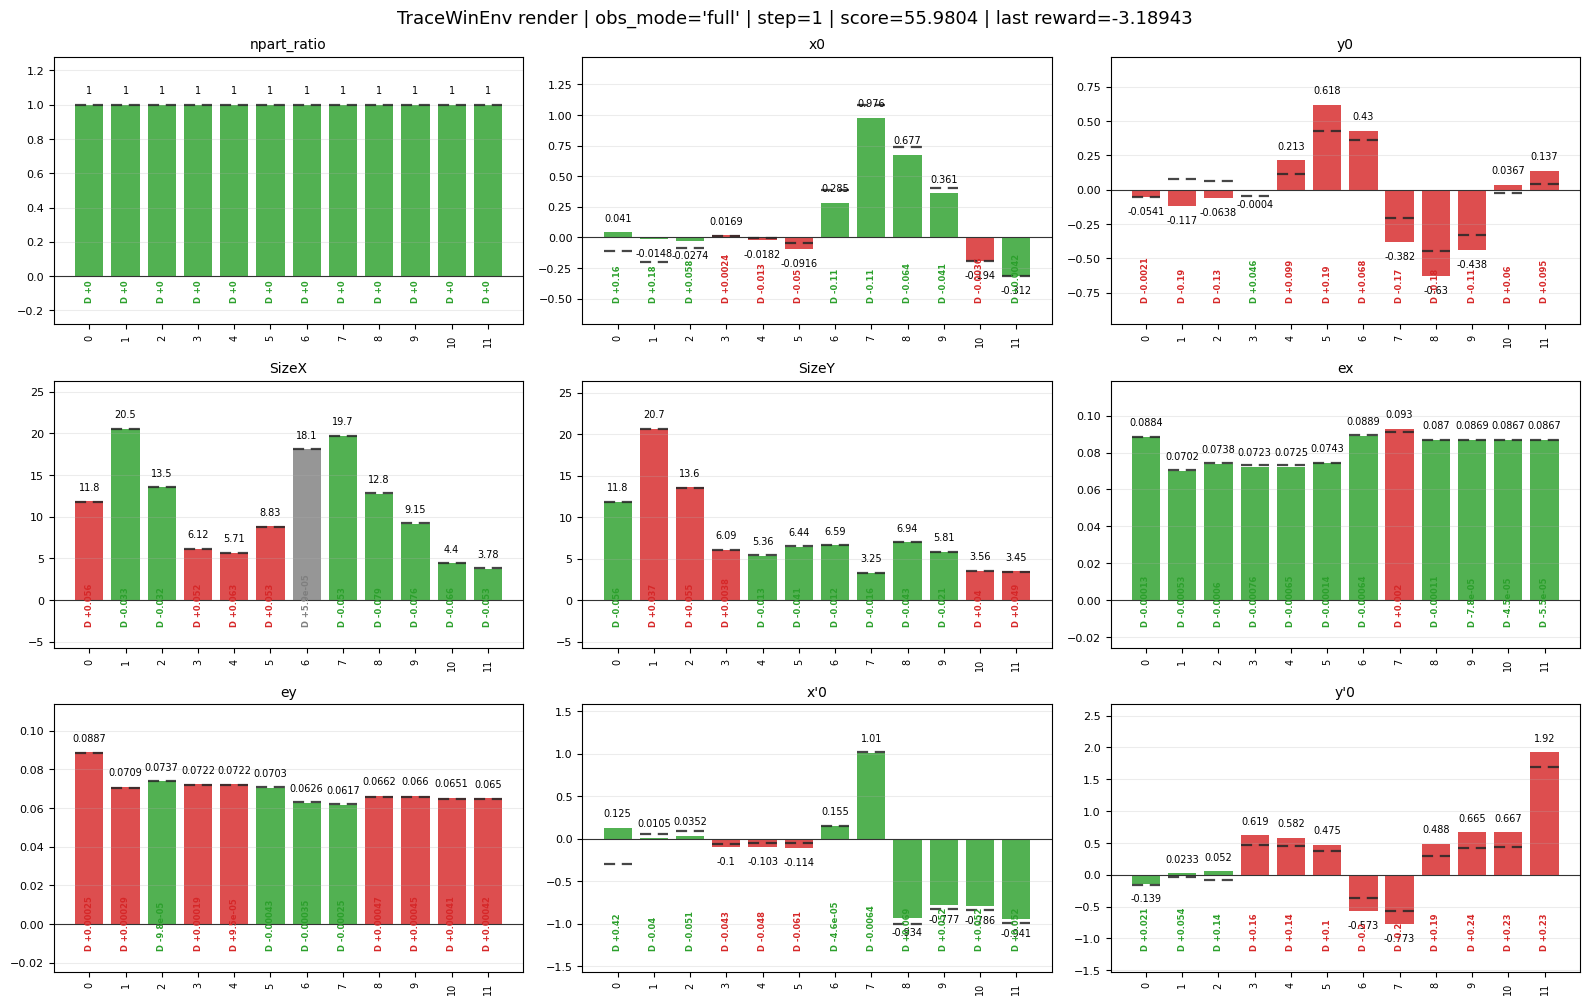

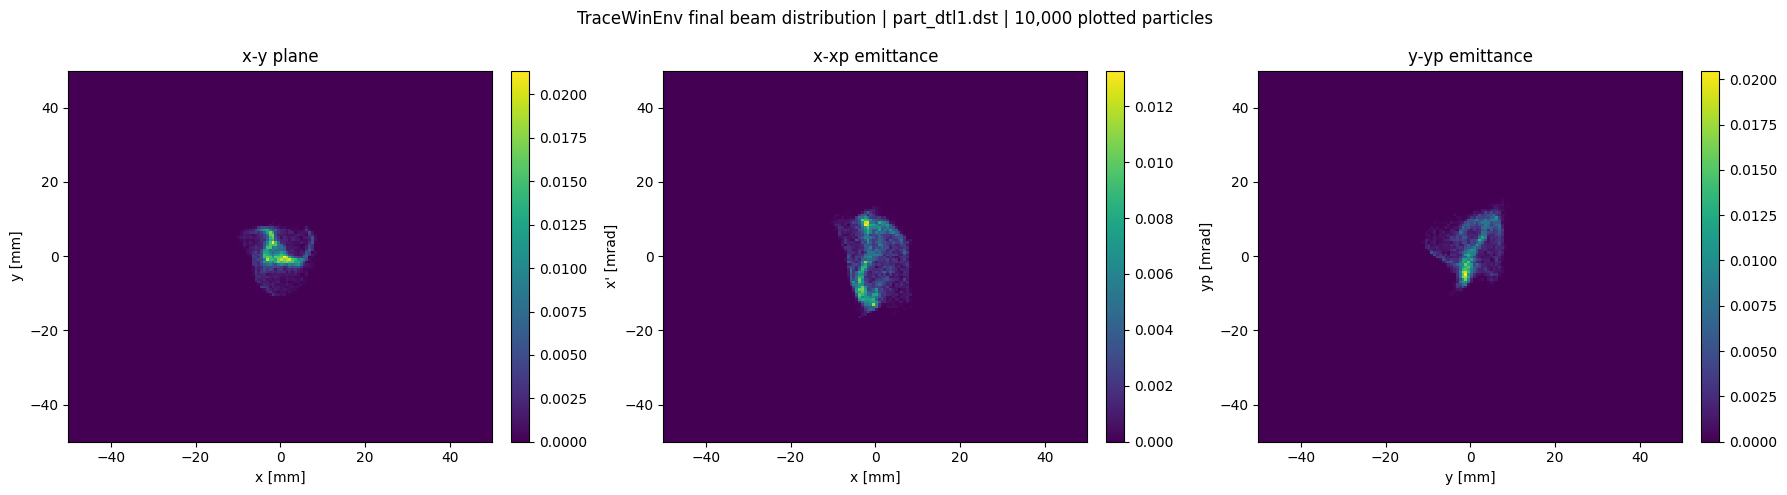

render_result type: <class 'tuple'>
render_result: (<Figure size 1600x1020 with 9 Axes>, <Figure size 1800x500 with 6 Axes>)


In [7]:
# Optional: render the feature figure and, if a .dst exists, the final beam distribution.
try:
    render_result = env.render(render_beam_distribution=True, max_particles=40000, bins=150)
    print('render_result type:', type(render_result))
    print('render_result:', render_result)
except Exception:
    traceback.print_exc()